In [121]:
using PlotlyJS
include("../model/pre_processing.jl")
include("../model/post_processing.jl")
include("./plotting.jl")
include("./processing.jl")
THRES = 0.001

0.001

In [174]:
# Example of envelopes with rho = 0.99 and different multiplier values
# folder_path = joinpath("..","output",  "RTS-GMLC_v21.1s" )
folder_path = joinpath("..","output",  "RTS-GMLC_v24.1su" )
    # solution_folders = ["n_1", "n_2"]
# solution_folders = ["n_$n" for n in range(1,7)]
day_ = 1
solution_folders = ["n_$(day_)"]

s_uc = [parquet_to_solution("s_uc", joinpath(folder_path, s)) for s in solution_folders]
s_ed = [parquet_to_solution("s_ed", joinpath(folder_path, s)) for s in solution_folders]
s_uc = NamedTuple(k => vcat([s[k] for s in s_uc if haskey(s, k)]...) for k in SOLUTION_KEYS)
s_ed = NamedTuple(k => vcat([s[k] for s in s_ed if haskey(s, k)]...) for k in SOLUTION_KEYS)
;

reading...
../output/RTS-GMLC_v24.1su/n_1/s_uc_demand.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_generation.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_storage.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_reserve.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_scalar.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_generation_parameters.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_storage_parameters.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_objective_function.parquet
../output/RTS-GMLC_v24.1su/n_1/s_uc_dual_variables.parquet
...done
reading...
../output/RTS-GMLC_v24.1su/n_1/s_ed_demand.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_generation.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_storage.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_scalar.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_generation_parameters.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_storage_parameters.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_objective_function.parquet
../output/RTS-GMLC_v24.1su/n_1/s_ed_dual_variables.parque

In [175]:
s_uc

(demand = 48×8 DataFrame
 Row │ hour   demand_MW  r_id     resource  LOL_MW    LGEN_MW   day    configu ⋯
     │ Int64  Float64?   Missing  String?   Float64?  Float64?  Int64  Symbol  ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │     1    1277.87  missing  system         0.0       0.0      1  base_ra ⋯
   2 │     2    1098.59  missing  system         0.0       0.0      1  base_ra
   3 │     3    1235.46  missing  system         0.0       0.0      1  base_ra
   4 │     4    1286.98  missing  system         0.0       0.0      1  base_ra
   5 │     5    1495.8   missing  system         0.0       0.0      1  base_ra ⋯
   6 │     6    1909.98  missing  system         0.0       0.0      1  base_ra
   7 │     7    2432.96  missing  system         0.0       0.0      1  base_ra
   8 │     8    1892.88  missing  system         0.0       0.0      1  base_ra
  ⋮  │   ⋮        ⋮         ⋮        ⋮         ⋮         ⋮        ⋮            ⋱
  42 │    18   

In [176]:
group_by = [:configuration, :day]
supply_uc, demand_uc = calculate_supply_demand(s_uc, union([:hour, :resource], group_by))
supply_ed, demand_ed = calculate_supply_demand(s_ed, union([:hour, :resource, :iteration], group_by))
reserve_uc = calculate_reserve(s_uc.reserve, nothing, union([:hour, :resource], group_by))
# reserve_ed = calculate_reserve(s_ed.reserve, nothing, union([:hour, :resource, :iteration], group_by))
commit_uc = combine(groupby(s_uc.generation, [:resource, :configuration, :day, :hour]), :commit => sum => :commit)
commit_ed = combine(groupby(s_ed.generation, [:resource, :configuration, :day, :iteration, :hour]), :commit => sum => :commit)
battery_reserve_uc = calculate_battery_reserve(s_uc.storage, reserve_uc)
;

In [177]:
# group_by_big= [:configuration, :day]
# gcdr_reserve_uc = combine(groupby(reserve_uc, [:configuration, :day, :resource]), [:reserve_up_MW,:reserve_down_MW]  .=> sum .=> [:reserve_up_MW,:reserve_down_MW])
# # combine(groupby(reserve_uc, union(group_by_big, [])), [:reserve_up_MW,:reserve_down_MW]  .=> sum .=> [:reserve_up_total_MW,:reserve_down_total_MW])
# gcdr_reserve_uc = leftjoin!(gcdr_reserve_uc,
# combine(groupby(reserve_uc, union(group_by_big, [:configuration, :day])), [:reserve_up_MW,:reserve_down_MW]  .=> sum .=> [:reserve_up_total_MW,:reserve_down_total_MW]),
# on = group_by_big
# )

# gcdr_reserve_uc.reserve_down_relative = gcdr_reserve_uc.reserve_down_MW ./ gcdr_reserve_uc.reserve_down_total_MW
# gcdr_reserve_uc.reserve_up_relative = gcdr_reserve_uc.reserve_up_MW ./ gcdr_reserve_uc.reserve_up_total_MW
# transform!(gcdr_reserve_uc, :configuration .=> ByRow(x -> parse_configuration_to_mu(x)) .=> :mu)
# sort!(gcdr_reserve_uc, :mu)
# ;
# gcdi_KPI_adequacy = calculate_adecuacy_gcdi_KPI(s_ed, s_uc)
# gcd_KPI_adequacy = calculate_adecuacy_gcd_KPI(gcdi_KPI_adequacy)
# ;

In [178]:
unique(supply_uc.configuration)

2-element Vector{Symbol}:
 :base_ramp_storage_envelopes_up_0_54_dn_0_54
 :base_ramp_storage_envelopes_up_1_dn_1

In [179]:
# day_ = 0
iteration_ = :demand_1
config_1 = unique(supply_uc.configuration)[1]
config_2 = unique(supply_uc.configuration)[2]
;

### UC

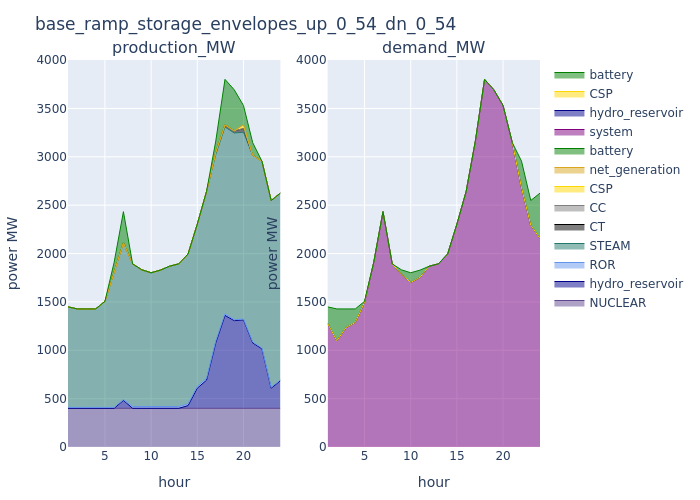

In [180]:
config_ = config_1
supply_uc_ = supply_uc[(supply_uc.configuration .== config_) .& (supply_uc.day .== day_), :]
demand_uc_ = demand_uc[(demand_uc.configuration .== config_) .& (demand_uc.day .== day_), :]
reserve_uc_ = reserve_uc[(reserve_uc.configuration .== config_) .& (reserve_uc.day .== day_), :]
plot_supply_demand(supply_uc_, demand_uc_, string(config_))

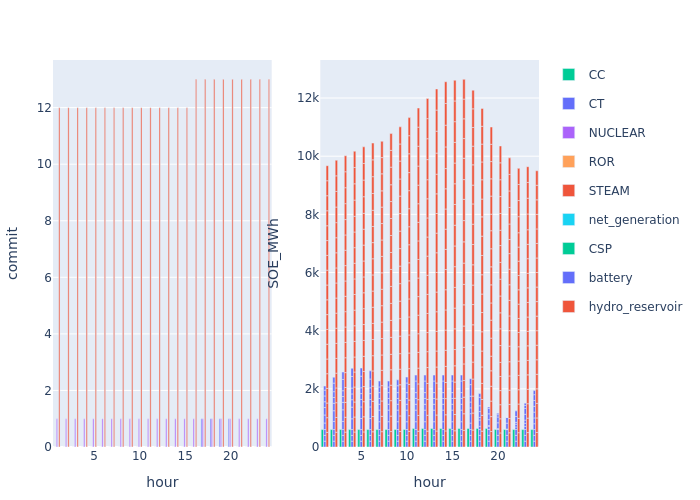

In [181]:
to_plot = commit_uc[(commit_uc.configuration .== config_1) .&  (commit_uc.day .== day_),:] 
p1 = plot(to_plot, x = :hour, y = :commit,  kind = "bar", color = :resource, stackgroup = 1) #Layout(barmode="stack"))

to_plot = s_uc.storage[(s_uc.storage.configuration .== config_1) .&  (s_uc.storage.day .== day_),:]
p2 = plot(to_plot, x = :hour , y = :SOE_MWh, color = :resource, kind = "bar", Layout(barmode="stack")) 
[p1 p2]

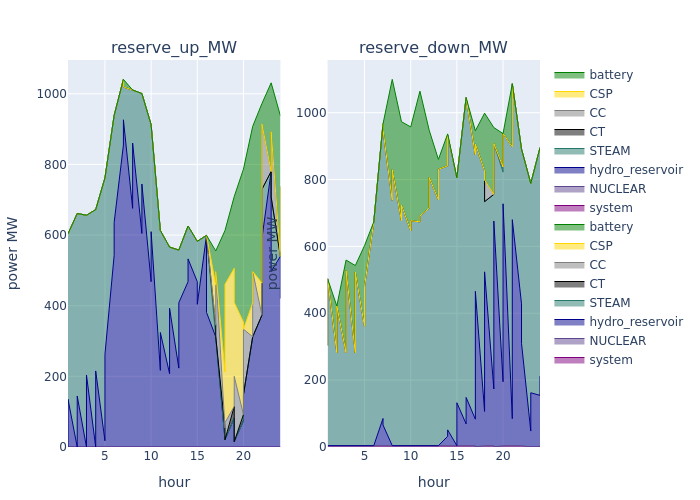

In [182]:
# p1 = plot_reserve_by_fieldy(reserve_uc_, :reserve_up_MW, :resource)
dissagregate_by_battery = false
if !dissagregate_by_battery
    p2 = plot_reserve(reserve_uc)
else
    p1 = plot_reserve_by_fieldy(s_uc.reserve[(s_uc.reserve.configuration .== config_) .&  (s_uc.reserve.day .== day_) .&  (s_uc.reserve.resource .== "battery"),:], :reserve_up_MW, :r_id)
    p2 = plot_reserve_by_fieldy(s_uc.reserve[(s_uc.reserve.configuration .== config_) .&  (s_uc.reserve.day .== day_) .&  (s_uc.reserve.resource .== "battery"),:], :reserve_down_MW, :r_id)
    [p1 p2]
end

In [183]:
# [plot_battery_reserve_(battery_reserve, :reserve_up_MW_eff), plot_battery_reserve_(battery_reserve, :reserve_down_MW_eff)]

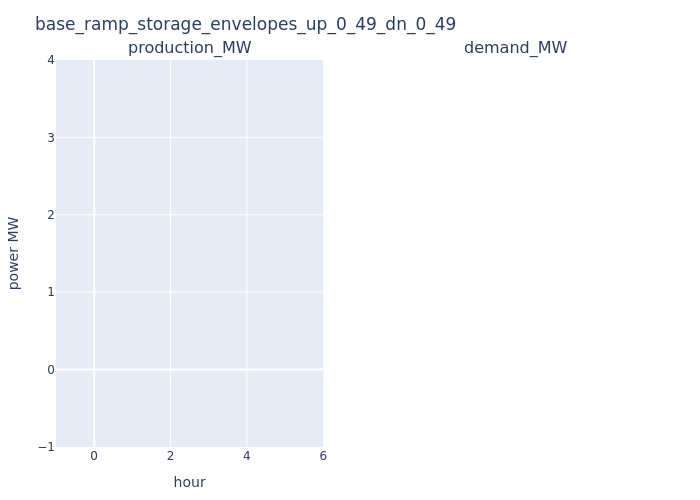

In [170]:
config_ = config_2
supply_uc_ = supply_uc[(supply_uc.configuration .== config_) .& (supply_uc.day .== day_), :]
demand_uc_ = demand_uc[(demand_uc.configuration .== config_) .& (demand_uc.day .== day_), :]
reserve_uc_ = reserve_uc[(reserve_uc.configuration .== config_) .& (reserve_uc.day .== day_), :]
plot_supply_demand(supply_uc_, demand_uc_, string(config_))

In [171]:
to_plot = commit_uc[(commit_uc.configuration .== config_2) .&  (commit_uc.day .== day_),:] 
p1 = plot(to_plot, x = :hour, y = :commit,  kind = "bar", color = :resource, stackgroup = 1) #Layout(barmode="stack"))

to_plot = s_uc.storage[(s_uc.storage.configuration .== config_2) .&  (s_uc.storage.day .== day_),:]
p2 = plot(to_plot, x = :hour , y = :SOE_MWh, color = :resource, kind = "bar", Layout(barmode="stack")) 
[p1 p2]

ErrorException: obsvals is empty, but order_keys is not

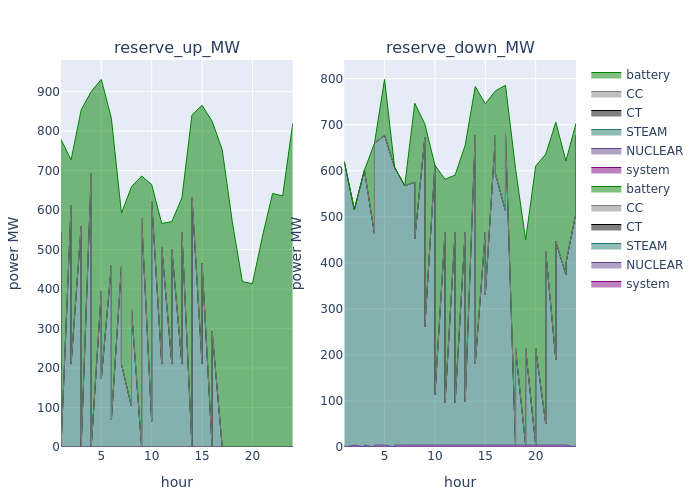

In [172]:

if !dissagregate_by_battery
    p2 = plot_reserve(reserve_uc)
else
    p1 = plot_reserve_by_fieldy(s_uc.reserve[(s_uc.reserve.configuration .== config_) .&  (s_uc.reserve.day .== day_) .&  (s_uc.reserve.resource .== "battery"),:], :reserve_up_MW, :r_id)
    p2 = plot_reserve_by_fieldy(s_uc.reserve[(s_uc.reserve.configuration .== config_) .&  (s_uc.reserve.day .== day_) .&  (s_uc.reserve.resource .== "battery"),:], :reserve_down_MW, :r_id)
    [p1 p2]
end

### ED

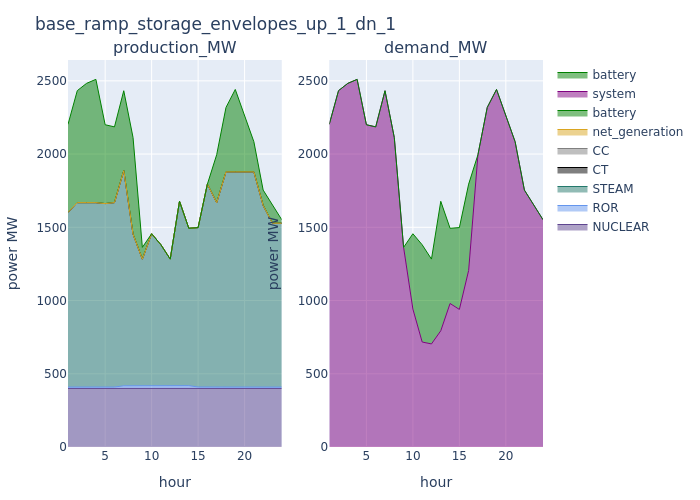

In [173]:
config_ = config_1
supply_ed_ = supply_ed[(supply_ed.configuration .== config_) .& (supply_ed.day .== day_) .& (supply_ed.iteration .== iteration_), :]
demand_ed_ = demand_ed[(demand_ed.configuration .== config_) .& (demand_ed.day .== day_) .& (demand_ed.iteration .== iteration_), :]
plot_supply_demand(supply_ed_, demand_ed_, string(config_))


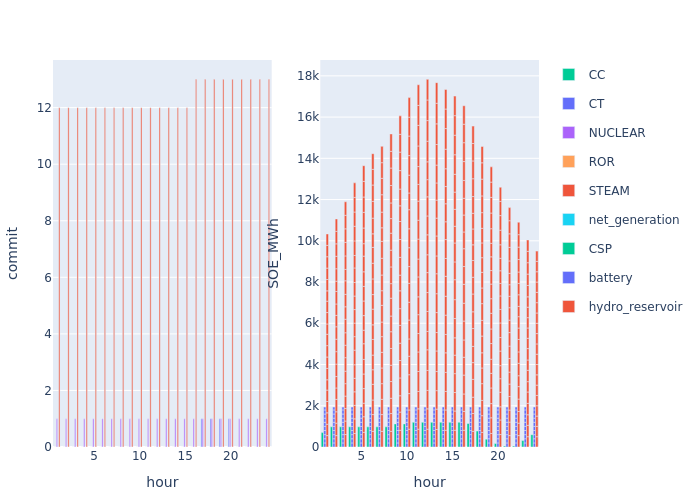

In [184]:
to_plot = commit_ed[(commit_ed.configuration .== config_) .&  (commit_ed.day .== day_) .&  (commit_ed.iteration .== iteration_),:] 
p1 = plot(to_plot, x = :hour, y = :commit,  kind = "bar", color = :resource, stackgroup = 1) #Layout(barmode="stack"))

to_plot = s_ed.storage[(s_ed.storage.configuration .== config_) .&  (s_ed.storage.day .== day_) .&  (s_ed.storage.iteration .== iteration_),:]
p2 = plot(to_plot, x = :hour , y = :SOE_MWh, color = :resource, kind = "bar", Layout(barmode="stack")) 
[p1 p2]

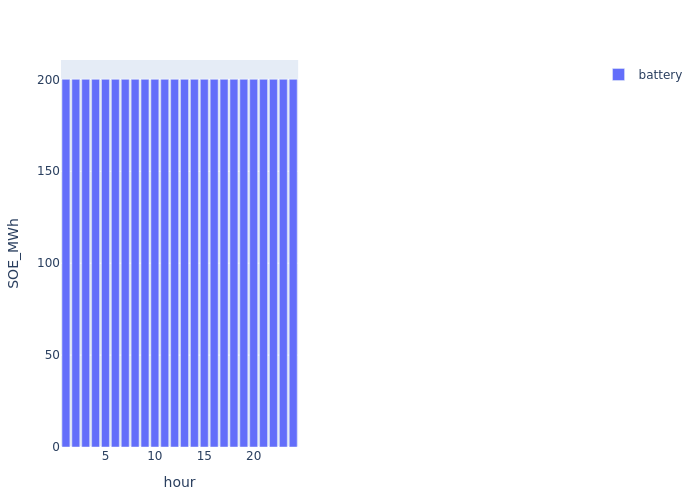

In [185]:
r_id_ = 102
to_plot = s_ed.storage[(s_ed.storage.configuration .== config_) .&  (s_ed.storage.day .== day_) .&  (s_ed.storage.iteration .== iteration_).&  (s_ed.storage.r_id .== r_id_),:]
p2 = plot(to_plot, x = :hour , y = :SOE_MWh, color = :resource, kind = "bar", Layout(barmode="stack")) 
[p2 plot()]

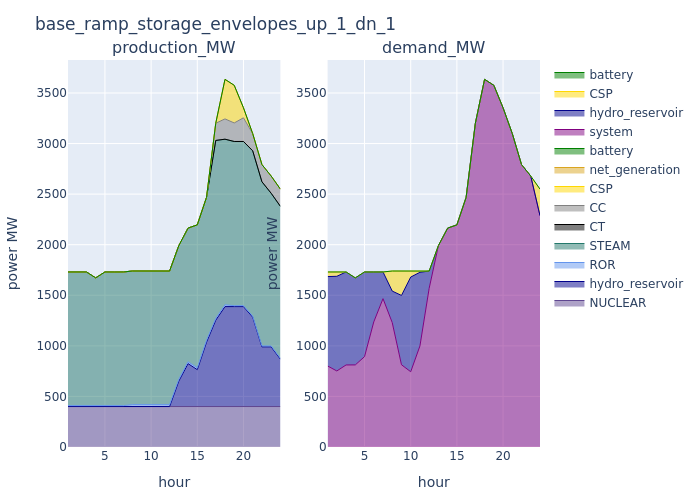

In [186]:
config_ =  config_2
supply_ed_ = supply_ed[(supply_ed.configuration .== config_) .& (supply_ed.day .== day_) .& (supply_ed.iteration .== iteration_), :]
demand_ed_ = demand_ed[(demand_ed.configuration .== config_) .& (demand_ed.day .== day_) .& (demand_ed.iteration .== iteration_), :]
plot_supply_demand(supply_ed_, demand_ed_, string(config_))


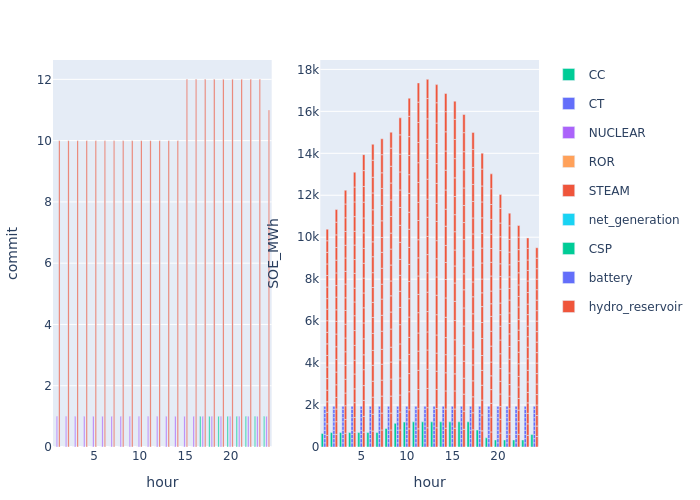

In [187]:
to_plot = commit_ed[(commit_ed.configuration .== config_) .&  (commit_ed.day .== day_) .&  (commit_ed.iteration .== iteration_),:] 
p1 = plot(to_plot, x = :hour, y = :commit, color = :resource, kind = "bar")

to_plot = s_ed.storage[(s_ed.storage.configuration .== config_) .&  (s_ed.storage.day .== day_) .&  (s_ed.storage.iteration .== iteration_),:]
p2 = plot(to_plot, x = :hour , y = :SOE_MWh, color = :resource, kind = "bar", Layout(barmode="stack")) 
[p1 p2]


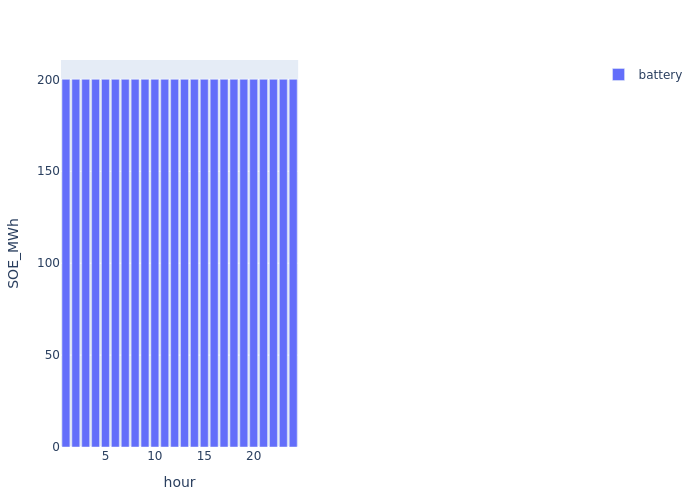

In [188]:
to_plot = s_ed.storage[(s_ed.storage.configuration .== config_) .&  (s_ed.storage.day .== day_) .&  (s_ed.storage.iteration .== iteration_).&  (s_ed.storage.r_id .== r_id_),:]
p2 = plot(to_plot, x = :hour , y = :SOE_MWh, color = :resource, kind = "bar", Layout(barmode="stack")) 
[p2 plot()]